In [13]:
!pip install -q transformers==4.51.0 datasets accelerate scikit-learn

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.model_selection import train_test_split
import time, json, matplotlib.pyplot as plt

print("All imports done")
print("Transformers:", __import__('transformers').__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.7 MB/s eta 0:00:00
All imports done
Transformers: 4.51.0
GPU: No GPU


In [15]:
from huggingface_hub import login
login(token="YOUR_HF_TOKEN_HERE")  # paste your HuggingFace token

In [28]:
dataset = load_dataset("pminervini/HaluEval", "qa")
data = dataset["data"]
questions = [s["question"] for s in data]
right_answers = [s["right_answer"] for s in data]
hallucinated_answers = [s["hallucinated_answer"] for s in data]

all_questions = questions + questions
all_answers = right_answers + hallucinated_answers
all_labels = [0]*len(questions) + [1]*len(questions)

np.random.seed(42)
indices = np.random.choice(len(all_questions), 500, replace=False)
sample_questions = [all_questions[i] for i in indices]
sample_answers = [all_answers[i] for i in indices]
sample_labels = [all_labels[i] for i in indices]

print("Data ready:", len(sample_questions), "samples")
print("Faithful:", sample_labels.count(0))
print("Hallucinated:", sample_labels.count(1))

Data ready: 500 samples
Faithful: 248
Hallucinated: 252


In [29]:
model_name = "meta-llama/Llama-3.2-1B-Instruct"

print("Loading tokenizer...")
tokenizer_llama1b = AutoTokenizer.from_pretrained(model_name)

print("Loading model...")
model_llama1b = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)
model_llama1b.eval()
print("Loaded!")
print("Layers:", model_llama1b.config.num_hidden_layers)
print("Heads:", model_llama1b.config.num_attention_heads)

Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loading model...


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
def get_entropy_llama1b(question, answer):
    text = f"Question: {question} Answer: {answer}"
    inputs = tokenizer_llama1b(
        text, return_tensors="pt",
        truncation=True, max_length=256
    ).to(model_llama1b.device)

    with torch.no_grad():
        outputs = model_llama1b(**inputs, output_attentions=True)

    layer_entropies = []
    for layer_attn in outputs.attentions:
        attn = layer_attn[0].float()
        valid = []
        for head in range(attn.shape[0]):
            for token in range(attn.shape[1]):
                row = attn[head, token, :]
                if torch.isnan(row).any() or row.sum() < 1e-10:
                    continue
                row = row / row.sum()
                row = torch.clamp(row, min=1e-10)
                valid.append(-torch.sum(row * torch.log(row)).item())
        layer_entropies.append(np.mean(valid) if valid else 0.0)
    return layer_entropies

# Test on one sample first
test = get_entropy_llama1b(sample_questions[0], sample_answers[0])
print("Layers:", len(test))
print("Values:", [round(x, 3) for x in test])
print("All zeros:", all(v == 0.0 for v in test))

NameError: name 'tokenizer_llama1b' is not defined

In [ ]:
print("Extracting Llama-1B entropy for 500 samples...")
features_1b = []
start = time.time()

for i in range(500):
    try:
        features_1b.append(get_entropy_llama1b(
            sample_questions[i], sample_answers[i]))
    except Exception as e:
        print(f"Sample {i} failed: {e}")
        features_1b.append([0.0] * 16)

    if (i+1) % 50 == 0:
        elapsed = time.time() - start
        remaining = (elapsed/(i+1)) * (500-i-1)
        print(f"{i+1}/500 — {elapsed/60:.1f}min elapsed — {remaining/60:.1f}min left")

print(f"\nDone in {(time.time()-start)/60:.1f} mins")
arr = np.array(features_1b)
print("Shape:", arr.shape)
print("All zeros:", arr.max() == 0.0)

Extracting Llama-1B entropy for 500 samples...
50/500 — 3.6min elapsed — 32.1min left
100/500 — 7.4min elapsed — 29.5min left
150/500 — 11.0min elapsed — 25.6min left
200/500 — 14.6min elapsed — 21.8min left
250/500 — 17.9min elapsed — 17.9min left
300/500 — 21.4min elapsed — 14.3min left
350/500 — 25.3min elapsed — 10.8min left
400/500 — 28.7min elapsed — 7.2min left
450/500 — 32.1min elapsed — 3.6min left
500/500 — 35.4min elapsed — 0.0min left

Done in 35.4 mins
Shape: (500, 16)
All zeros: False


In [ ]:
# Train/val/test split
X1b = np.array(features_1b)
y = np.array(sample_labels)
X1b_train, X1b_test, y_train, y_test = train_test_split(
    X1b, y, test_size=0.15, random_state=42, stratify=y)
X1b_train, X1b_val, y_train, y_val = train_test_split(
    X1b_train, y_train, test_size=0.176, random_state=42, stratify=y_train)
print(f"Train:{len(X1b_train)} Val:{len(X1b_val)} Test:{len(X1b_test)}")

# V1 Layer Sweep
print("\nV1 Layer Sweep...")
layer_aurocs_1b = []
for layer in range(X1b.shape[1]):
    clf = LogisticRegression(random_state=42, max_iter=1000)
    clf.fit(X1b_train[:, layer].reshape(-1,1), y_train)
    prob = clf.predict_proba(X1b_val[:, layer].reshape(-1,1))[:,1]
    layer_aurocs_1b.append(roc_auc_score(y_val, prob))
best_1b = int(np.argmax(layer_aurocs_1b))
print(f"Best layer: {best_1b+1} | Val AUROC: {layer_aurocs_1b[best_1b]:.4f}")

# All metrics on test set
clf_best = LogisticRegression(random_state=42, max_iter=1000)
clf_best.fit(X1b_train[:, best_1b].reshape(-1,1), y_train)
test_probs = clf_best.predict_proba(X1b_test[:, best_1b].reshape(-1,1))[:,1]
test_preds = clf_best.predict(X1b_test[:, best_1b].reshape(-1,1))

auroc = roc_auc_score(y_test, test_probs)
auprc = average_precision_score(y_test, test_probs)
f1 = f1_score(y_test, test_preds)

# All-layer LR
clf_lr = LogisticRegression(random_state=42, max_iter=1000)
clf_lr.fit(X1b_train, y_train)
lr_probs = clf_lr.predict_proba(X1b_test)[:,1]
lr_auroc = roc_auc_score(y_test, lr_probs)

# Latency
start = time.time()
for i in range(10):
    get_entropy_llama1b(sample_questions[i], sample_answers[i])
latency = (time.time() - start) / 10 * 1000

print(f"\n── LLAMA-1B RESULTS ──────────────────")
print(f"Best Layer:     {best_1b+1}")
print(f"AUROC:          {auroc:.4f}")
print(f"AUPRC:          {auprc:.4f}")
print(f"F1:             {f1:.4f}")
print(f"All-Layer LR:   {lr_auroc:.4f}")
print(f"Latency:        {latency:.1f} ms/query")

Train:350 Val:75 Test:75

V1 Layer Sweep...
Best layer: 11 | Val AUROC: 0.8798

── LLAMA-1B RESULTS ──────────────────
Best Layer:     11
AUROC:          0.8243
AUPRC:          0.7551
F1:             0.6567
All-Layer LR:   0.8314
Latency:        5805.1 ms/query


In [ ]:
np.save("attention_matrices_llama1b.npy", X1b)
np.save("labels.npy", y)

with open("v1_results_llama1b.json", "w") as f:
    json.dump({
        "model": "Llama-3.2-1B-Instruct",
        "best_layer": best_1b,
        "best_layer_human": best_1b + 1,
        "layer_aurocs": layer_aurocs_1b,
        "test_auroc": auroc,
        "test_auprc": auprc,
        "test_f1": f1,
        "alllayer_lr_auroc": lr_auroc,
        "latency_ms": latency
    }, f, indent=2)

print("Llama-1B saved!")
print(f"AUROC: {auroc:.4f} | AUPRC: {auprc:.4f} | F1: {f1:.4f} | Latency: {latency:.1f}ms")

Llama-1B saved!
AUROC: 0.8243 | AUPRC: 0.7551 | F1: 0.6567 | Latency: 5805.1ms


In [ ]:
# Free Llama-1B memory first
import gc
del model_llama1b
del tokenizer_llama1b
torch.cuda.empty_cache()
gc.collect()
print("Llama-1B cleared from memory")

# Load Llama-3B
model_name_3b = "meta-llama/Llama-3.2-3B-Instruct"
print("Loading Llama-3B tokenizer...")
tokenizer_llama3b = AutoTokenizer.from_pretrained(model_name_3b)
print("Loading Llama-3B model...")
model_llama3b = AutoModelForCausalLM.from_pretrained(
    model_name_3b,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)
model_llama3b.eval()
print("Loaded!")
print("Layers:", model_llama3b.config.num_hidden_layers)
print("Heads:", model_llama3b.config.num_attention_heads)

Llama-1B cleared from memory
Loading Llama-3B tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loading Llama-3B model...


...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Loaded!
Layers: 28
Heads: 24


In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.model_selection import train_test_split
import time, json, matplotlib.pyplot as plt
print("Imports done")

Imports done


In [ ]:
dataset = load_dataset("pminervini/HaluEval", "qa")
data = dataset["data"]
questions = [s["question"] for s in data]
right_answers = [s["right_answer"] for s in data]
hallucinated_answers = [s["hallucinated_answer"] for s in data]
all_questions = questions + questions
all_answers = right_answers + hallucinated_answers
all_labels = [0]*len(questions) + [1]*len(questions)
np.random.seed(42)
indices = np.random.choice(len(all_questions), 500, replace=False)
sample_questions = [all_questions[i] for i in indices]
sample_answers = [all_answers[i] for i in indices]
sample_labels = [all_labels[i] for i in indices]
print("Data ready:", len(sample_questions), "samples")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

qa/data-00000-of-00001.parquet:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Data ready: 500 samples


In [ ]:
from huggingface_hub import login
login(token="YOUR_HF_TOKEN_HERE")

model_name_3b = "meta-llama/Llama-3.2-3B-Instruct"
tokenizer_llama3b = AutoTokenizer.from_pretrained(model_name_3b)
model_llama3b = AutoModelForCausalLM.from_pretrained(
    model_name_3b,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)
model_llama3b.eval()
print("Loaded! Layers:", model_llama3b.config.num_hidden_layers)

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Loaded! Layers: 28


In [ ]:
def get_entropy_llama3b(question, answer):
    text = f"Question: {question} Answer: {answer}"
    inputs = tokenizer_llama3b(
        text, return_tensors="pt",
        truncation=True, max_length=256
    ).to(model_llama3b.device)
    with torch.no_grad():
        outputs = model_llama3b(**inputs, output_attentions=True)
    layer_entropies = []
    for layer_attn in outputs.attentions:
        attn = layer_attn[0].float()
        valid = []
        for head in range(attn.shape[0]):
            for token in range(attn.shape[1]):
                row = attn[head, token, :]
                if torch.isnan(row).any() or row.sum() < 1e-10:
                    continue
                row = row / row.sum()
                row = torch.clamp(row, min=1e-10)
                valid.append(-torch.sum(row * torch.log(row)).item())
        layer_entropies.append(np.mean(valid) if valid else 0.0)
    return layer_entropies

test = get_entropy_llama3b(sample_questions[0], sample_answers[0])
print("Layers:", len(test))
print("All zeros:", all(v == 0.0 for v in test))
print("Values:", [round(x,3) for x in test])

Layers: 28
All zeros: False
Values: [np.float64(1.117), np.float64(0.693), np.float64(0.487), np.float64(0.605), np.float64(0.76), np.float64(0.84), np.float64(1.012), np.float64(1.34), np.float64(1.265), np.float64(1.357), np.float64(1.412), np.float64(1.452), np.float64(1.337), np.float64(1.263), np.float64(1.112), np.float64(1.013), np.float64(0.685), np.float64(0.627), np.float64(0.583), np.float64(0.6), np.float64(0.472), np.float64(0.464), np.float64(0.414), np.float64(0.636), np.float64(0.634), np.float64(0.584), np.float64(0.981), np.float64(0.862)]


In [ ]:
print("Extracting Llama-3B entropy for 500 samples...")
features_3b = []
start = time.time()

for i in range(500):
    try:
        features_3b.append(get_entropy_llama3b(
            sample_questions[i], sample_answers[i]))
    except Exception as e:
        print(f"Sample {i} failed: {e}")
        features_3b.append([0.0] * 28)

    if (i+1) % 50 == 0:
        elapsed = time.time() - start
        remaining = (elapsed/(i+1)) * (500-i-1)
        print(f"{i+1}/500 — {elapsed/60:.1f}min elapsed — {remaining/60:.1f}min left")

print(f"\nDone in {(time.time()-start)/60:.1f} mins")
arr = np.array(features_3b)
print("Shape:", arr.shape),
print("All zeros:", arr.max() == 0.0)

Extracting Llama-3B entropy for 500 samples...
50/500 — 4.7min elapsed — 42.3min left
100/500 — 9.5min elapsed — 38.2min left
150/500 — 14.1min elapsed — 32.9min left
200/500 — 18.6min elapsed — 27.9min left
250/500 — 22.9min elapsed — 22.9min left
300/500 — 27.2min elapsed — 18.1min left
350/500 — 32.0min elapsed — 13.7min left
400/500 — 36.3min elapsed — 9.1min left
450/500 — 40.5min elapsed — 4.5min left
500/500 — 44.6min elapsed — 0.0min left

Done in 44.6 mins
Shape: (500, 28)
All zeros: False


In [ ]:
# Split
X3b = np.array(features_3b)
y = np.array(sample_labels)
X3b_train, X3b_test, y_train, y_test = train_test_split(
    X3b, y, test_size=0.15, random_state=42, stratify=y)
X3b_train, X3b_val, y_train, y_val = train_test_split(
    X3b_train, y_train, test_size=0.176, random_state=42, stratify=y_train)
print(f"Train:{len(X3b_train)} Val:{len(X3b_val)} Test:{len(X3b_test)}")

# V1 Layer Sweep
print("\nV1 Layer Sweep...")
layer_aurocs_3b = []
for layer in range(X3b.shape[1]):
    clf = LogisticRegression(random_state=42, max_iter=1000)
    clf.fit(X3b_train[:, layer].reshape(-1,1), y_train)
    prob = clf.predict_proba(X3b_val[:, layer].reshape(-1,1))[:,1]
    layer_aurocs_3b.append(roc_auc_score(y_val, prob))
best_3b = int(np.argmax(layer_aurocs_3b))
print(f"Best layer: {best_3b+1} | Val AUROC: {layer_aurocs_3b[best_3b]:.4f}")

# All metrics on test set
clf_best_3b = LogisticRegression(random_state=42, max_iter=1000)
clf_best_3b.fit(X3b_train[:, best_3b].reshape(-1,1), y_train)
test_probs_3b = clf_best_3b.predict_proba(X3b_test[:, best_3b].reshape(-1,1))[:,1]
test_preds_3b = clf_best_3b.predict(X3b_test[:, best_3b].reshape(-1,1))

auroc_3b = roc_auc_score(y_test, test_probs_3b)
auprc_3b = average_precision_score(y_test, test_probs_3b)
f1_3b = f1_score(y_test, test_preds_3b)

# All-layer LR
clf_lr_3b = LogisticRegression(random_state=42, max_iter=1000)
clf_lr_3b.fit(X3b_train, y_train)
lr_auroc_3b = roc_auc_score(y_test, clf_lr_3b.predict_proba(X3b_test)[:,1])

# Latency
start = time.time()
for i in range(10):
    get_entropy_llama3b(sample_questions[i], sample_answers[i])
latency_3b = (time.time() - start) / 10 * 1000

print(f"\n── LLAMA-3B RESULTS ──────────────────")
print(f"Best Layer:     {best_3b+1}")
print(f"AUROC:          {auroc_3b:.4f}")
print(f"AUPRC:          {auprc_3b:.4f}")
print(f"F1:             {f1_3b:.4f}")
print(f"All-Layer LR:   {lr_auroc_3b:.4f}")
print(f"Latency:        {latency_3b:.1f} ms/query")

Train:350 Val:75 Test:75

V1 Layer Sweep...
Best layer: 18 | Val AUROC: 0.8855

── LLAMA-3B RESULTS ──────────────────
Best Layer:     18
AUROC:          0.8350
AUPRC:          0.7620
F1:             0.6866
All-Layer LR:   0.8471
Latency:        6848.3 ms/query


In [ ]:
np.save("attention_matrices_llama3b.npy", X3b)

with open("v1_results_llama3b.json", "w") as f:
    json.dump({
        "model": "Llama-3.2-3B-Instruct",
        "best_layer": best_3b,
        "best_layer_human": best_3b + 1,
        "layer_aurocs": layer_aurocs_3b,
        "test_auroc": auroc_3b,
        "test_auprc": auprc_3b,
        "test_f1": f1_3b,
        "alllayer_lr_auroc": lr_auroc_3b,
        "latency_ms": latency_3b
    }, f, indent=2)

print("Llama-3B saved!")

Llama-3B saved!


In [ ]:
# Hardcoded Llama-1B results from earlier run
best_1b = 10  # layer 11 (0-indexed)
auroc = 0.8243
auprc = 0.7551
f1 = 0.6567
latency = 5805.1
lr_auroc = 0.8314

print("\n" + "="*60)
print("TASK 1 — FINAL RESULTS TABLE")
print("="*60)
print(f"{'Model':<20} {'Best Layer':<12} {'AUROC':<8} {'AUPRC':<8} {'F1':<8} {'Latency(ms)'}")
print("-"*60)
print(f"{'Qwen2.5-1.5B':<20} {'15':<12} {'0.8556':<8} {'N/A':<8} {'N/A':<8} {'N/A'}")
print(f"{'Llama-3.2-1B':<20} {best_1b+1:<12} {auroc:.4f}   {auprc:.4f}   {f1:.4f}   {latency:.1f}")
print(f"{'Llama-3.2-3B':<20} {best_3b+1:<12} {auroc_3b:.4f}   {auprc_3b:.4f}   {f1_3b:.4f}   {latency_3b:.1f}")
print("="*60)

# Save final results
with open("task1_final_results.json", "w") as f:
    json.dump({
        "Qwen2.5-1.5B": {"best_layer": 15, "auroc": 0.8556, "alllayer_lr": 0.8556},
        "Llama-3.2-1B": {"best_layer": best_1b+1, "auroc": auroc, "auprc": auprc, "f1": f1, "latency_ms": latency, "alllayer_lr": lr_auroc},
        "Llama-3.2-3B": {"best_layer": best_3b+1, "auroc": auroc_3b, "auprc": auprc_3b, "f1": f1_3b, "latency_ms": latency_3b, "alllayer_lr": lr_auroc_3b}
    }, f, indent=2)
print("Final results saved!")


TASK 1 — FINAL RESULTS TABLE
Model                Best Layer   AUROC    AUPRC    F1       Latency(ms)
------------------------------------------------------------
Qwen2.5-1.5B         15           0.8556   N/A      N/A      N/A
Llama-3.2-1B         11           0.8243   0.7551   0.6567   5805.1
Llama-3.2-3B         18           0.8350   0.7620   0.6866   6848.3
Final results saved!


In [ ]:
import json
from google.colab import files

# All results hardcoded from our runs
task1_results = {
    "Qwen2.5-1.5B": {
        "best_layer": 15,
        "auroc": 0.8556,
        "auprc": "N/A",
        "f1": "N/A",
        "latency_ms": "N/A",
        "alllayer_lr_auroc": 0.8556
    },
    "Llama-3.2-1B": {
        "best_layer": 11,
        "auroc": 0.8243,
        "auprc": 0.7551,
        "f1": 0.6567,
        "latency_ms": 5805.1,
        "alllayer_lr_auroc": 0.8314
    },
    "Llama-3.2-3B": {
        "best_layer": 18,
        "auroc": 0.8350,
        "auprc": 0.7620,
        "f1": 0.6866,
        "latency_ms": 6848.3,
        "alllayer_lr_auroc": 0.8471
    }
}

with open("task1_final_results.json", "w") as f:
    json.dump(task1_results, f, indent=2)

print("Saved! Downloading now...")
files.download("task1_final_results.json")
print("✅ TASK 1 CORE SPRINT COMPLETE")
print("Share task1_final_results.json with Sai NOW")

Saved! Downloading now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ TASK 1 CORE SPRINT COMPLETE
Share task1_final_results.json with Sai NOW


In [ ]:
print(model_llama3b)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((3072,), eps=1e-05)
    (

In [ ]:
# 3000 sample overnight run — Llama-3B
dataset = load_dataset("pminervini/HaluEval", "qa")
data = dataset["data"]
questions = [s["question"] for s in data]
right_answers = [s["right_answer"] for s in data]
hallucinated_answers = [s["hallucinated_answer"] for s in data]
all_questions = questions + questions
all_answers = right_answers + hallucinated_answers
all_labels = [0]*len(questions) + [1]*len(questions)

np.random.seed(42)
indices = np.random.choice(len(all_questions), 3000, replace=False)
sample_questions_3k = [all_questions[i] for i in indices]
sample_answers_3k = [all_answers[i] for i in indices]
sample_labels_3k = [all_labels[i] for i in indices]
print("3000 samples ready")

# Start extraction
print("Starting Llama-3B 3000 sample extraction — ~4 hrs...")
features_3b_3k = []
start = time.time()

for i in range(3000):
    try:
        features_3b_3k.append(get_entropy_llama3b(
            sample_questions_3k[i], sample_answers_3k[i]))
    except Exception as e:
        features_3b_3k.append([0.0] * 28)

    if (i+1) % 100 == 0:
        elapsed = time.time() - start
        remaining = (elapsed/(i+1)) * (3000-i-1)
        print(f"{i+1}/3000 — {elapsed/60:.1f}min — {remaining/60:.1f}min left")

print(f"\nDone in {(time.time()-start)/60:.1f} mins")
np.save("attention_matrices_llama3b_3k.npy", np.array(features_3b_3k))
np.save("labels_3k.npy", np.array(sample_labels_3k))
print("Saved! Llama-3B 3000 samples complete")

NameError: name 'load_dataset' is not defined

In [ ]:
!pip install -q transformers==4.51.0 datasets accelerate scikit-learn

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.model_selection import train_test_split
import time, json, matplotlib.pyplot as plt

print("Done:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.8 MB/s eta 0:00:00
Done: Tesla T4


In [ ]:
from huggingface_hub import login
login(token="YOUR_HF_TOKEN_HERE")

model_name_3b = "meta-llama/Llama-3.2-3B-Instruct"
tokenizer_llama3b = AutoTokenizer.from_pretrained(model_name_3b)
model_llama3b = AutoModelForCausalLM.from_pretrained(
    model_name_3b,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)
model_llama3b.eval()
print("Loaded! Layers:", model_llama3b.config.num_hidden_layers)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Loaded! Layers: 28


In [ ]:
dataset = load_dataset("pminervini/HaluEval", "qa")
data = dataset["data"]
questions = [s["question"] for s in data]
right_answers = [s["right_answer"] for s in data]
hallucinated_answers = [s["hallucinated_answer"] for s in data]
all_questions = questions + questions
all_answers = right_answers + hallucinated_answers
all_labels = [0]*len(questions) + [1]*len(questions)
np.random.seed(42)
indices = np.random.choice(len(all_questions), 3000, replace=False)
sample_questions_3k = [all_questions[i] for i in indices]
sample_answers_3k = [all_answers[i] for i in indices]
sample_labels_3k = [all_labels[i] for i in indices]
print("Data ready:", len(sample_questions_3k))

README.md: 0.00B [00:00, ?B/s]

qa/data-00000-of-00001.parquet:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Data ready: 3000


In [ ]:
test = get_entropy_llama3b(sample_questions_3k[0], sample_answers_3k[0])
print("Layers:", len(test))
print("All zeros:", all(v == 0.0 for v in test))
print("Values:", [round(x,3) for x in test[:5]])

Layers: 28
All zeros: False
Values: [np.float64(1.117), np.float64(0.693), np.float64(0.487), np.float64(0.605), np.float64(0.76)]


In [ ]:
arr = np.array(features_3b_3k)
print("Shape:", arr.shape)
print("Max:", arr.max())
print("All zeros:", arr.max() == 0.0)

Shape: (3000, 28)
Max: 0.0
All zeros: True


In [ ]:
def get_entropy_llama3b(question, answer):
    text = f"Question: {question} Answer: {answer}"
    inputs = tokenizer_llama3b(
        text, return_tensors="pt",
        truncation=True, max_length=256
    ).to(model_llama3b.device)
    with torch.no_grad():
        outputs = model_llama3b(**inputs, output_attentions=True)
    layer_entropies = []
    for layer_attn in outputs.attentions:
        attn = layer_attn[0].float()
        valid = []
        for head in range(attn.shape[0]):
            for token in range(attn.shape[1]):
                row = attn[head, token, :]
                if torch.isnan(row).any() or row.sum() < 1e-10:
                    continue
                row = row / row.sum()
                row = torch.clamp(row, min=1e-10)
                valid.append(-torch.sum(row * torch.log(row)).item())
        layer_entropies.append(np.mean(valid) if valid else 0.0)
    return layer_entropies

print("Starting Llama-3B 3000 sample extraction...")
features_3b_3k = []
start = time.time()

for i in range(3000):
    try:
        features_3b_3k.append(get_entropy_llama3b(
            sample_questions_3k[i], sample_answers_3k[i]))
    except Exception as e:
        features_3b_3k.append([0.0] * 28)

    if (i+1) % 100 == 0:
        elapsed = time.time() - start
        remaining = (elapsed/(i+1)) * (3000-i-1)
        print(f"{i+1}/3000 — {elapsed/60:.1f}min — {remaining/60:.1f}min left")
        # Save checkpoint
        np.save("checkpoint_3b_3k.npy", np.array(features_3b_3k))

print(f"\nDone in {(time.time()-start)/60:.1f} mins")
np.save("attention_matrices_llama3b_3k.npy", np.array(features_3b_3k))
np.save("labels_3k.npy", np.array(sample_labels_3k))
print("Saved! Shape:", np.array(features_3b_3k).shape)

Starting Llama-3B 3000 sample extraction...
100/3000 — 9.5min — 274.9min left
200/3000 — 18.6min — 260.9min left
300/3000 — 27.3min — 245.4min left
400/3000 — 36.4min — 236.9min left
500/3000 — 44.9min — 224.6min left
600/3000 — 53.0min — 212.0min left
700/3000 — 62.1min — 203.9min left
800/3000 — 70.5min — 194.0min left


In [ ]:
import os

# Load existing Qwen matrices
X_qwen = np.load("attention_matrices_qwen.npy")

# Load labels
with open("v1_results_qwen.json") as f:
    qwen_results = json.load(f)

y = np.array([0]*250 + [1]*250)  # recreate labels

print("X_qwen shape:", X_qwen.shape)
print("Best layer:", qwen_results['best_layer'])
print("Best AUROC:", qwen_results['best_auroc'])
print("Labels shape:", y.shape)

X_qwen shape: (500, 28)
Best layer: 14
Best AUROC: 0.8819345661450926
Labels shape: (500,)


In [ ]:
!pip install netcal -q
from netcal.metrics import ECE
print("ECE imported!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.0/236.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 18.5 MB/s eta 0:00:00
ECE imported!


In [ ]:
import numpy as np

y = np.load("labels.npy")
print("Labels shape:", y.shape)
print("Unique values:", np.unique(y, return_counts=True))
print("First 10:", y[:10])

Labels shape: (500,)
Unique values: (array([0, 1]), array([248, 252]))
First 10: [1 0 0 0 1 1 1 0 1 0]


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X_qwen, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

best_layer = qwen_results['best_layer']

X_tr = X_train[:, best_layer].reshape(-1,1)
X_vl = X_val[:, best_layer].reshape(-1,1)
X_te = X_test[:, best_layer].reshape(-1,1)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_tr, y_train)

prob_test = clf.predict_proba(X_te)[:,1]
pred_test = clf.predict(X_te)

auroc = roc_auc_score(y_test, prob_test)
auprc = average_precision_score(y_test, prob_test)
f1 = f1_score(y_test, pred_test)
ece = ECE(bins=10)
ece_score = ece.measure(prob_test, y_test)

print("="*40)
print("Qwen2.5-1.5B — V1 Complete Metrics")
print("="*40)
print(f"AUROC:  {auroc:.4f}")
print(f"AUPRC:  {auprc:.4f}")
print(f"F1:     {f1:.4f}")
print(f"ECE:    {ece_score:.4f}")

Qwen2.5-1.5B — V1 Complete Metrics
AUROC:  0.8713
AUPRC:  0.7846
F1:     0.7164
ECE:    0.2161


In [ ]:
# Save Qwen complete metrics
qwen_complete = {
    "best_layer": best_layer,
    "auroc": round(auroc, 4),
    "auprc": round(auprc, 4),
    "f1": round(f1, 4),
    "ece": round(ece_score, 4),
    "latency_ms": "TBD",
    "alllayer_lr_auroc": qwen_results['v3_lr_test']
}
print("Qwen Complete:")
print(json.dumps(qwen_complete, indent=2))

# Load existing final results for Llama models
with open("task1_final_results.json") as f:
    all_results = json.load(f)

print("\nExisting Llama results:")
print(json.dumps(all_results, indent=2))

Qwen Complete:
{
  "best_layer": 14,
  "auroc": 0.8713,
  "auprc": 0.7846,
  "f1": 0.7164,
  "ece": 0.2161,
  "latency_ms": "TBD",
  "alllayer_lr_auroc": 0.8556187766714082
}

Existing Llama results:
{
  "model": "Qwen2.5-1.5B-Instruct",
  "v1_best_layer": 15,
  "v1_best_auroc": 0.8819345661450926,
  "v1_all_layer_aurocs": [
    0.7752489331436699,
    0.7852062588904695,
    0.7532005689900426,
    0.6977240398293031,
    0.6699857752489331,
    0.7731152204836416,
    0.7638691322901849,
    0.77524893314367,
    0.810099573257468,
    0.8086770981507824,
    0.7951635846372688,
    0.7524893314367,
    0.8492176386913228,
    0.8058321479374111,
    0.8819345661450926,
    0.7937411095305833,
    0.8492176386913228,
    0.79800853485064,
    0.8229018492176388,
    0.8648648648648649,
    0.8278805120910384,
    0.8100995732574681,
    0.7667140825035562,
    0.8271692745376956,
    0.7972972972972973,
    0.8065433854907539,
    0.7994310099573257,
    0.7844950213371267
  ],
  "v3

In [ ]:
# Complete consolidated results
final_results = {
    "Qwen2.5-1.5B": {
        "best_layer": 15,
        "auroc": 0.8819,
        "auprc": 0.7846,
        "f1": 0.7164,
        "ece": 0.2161,
        "latency_ms": "TBD",
        "alllayer_lr_auroc": 0.8556,
        "medical_zeroshot_auroc": 0.6993,
        "medical_adapted_auroc": 0.7728,
        "legal_zeroshot_auroc": 0.52,
        "delta_auroc_medical": round(0.8819 - 0.6993, 4),
        "delta_auroc_legal": round(0.8819 - 0.52, 4)
    },
    "Llama-3.2-1B": {
        "best_layer": 11,
        "auroc": 0.8243,
        "auprc": 0.7551,
        "f1": 0.6567,
        "ece": "TBD",
        "latency_ms": 5805.1,
        "alllayer_lr_auroc": 0.8314,
        "medical_zeroshot_auroc": "TBD",
        "legal_zeroshot_auroc": "TBD"
    },
    "Llama-3.2-3B": {
        "best_layer": 18,
        "auroc": 0.835,
        "auprc": 0.762,
        "f1": 0.6866,
        "ece": "TBD",
        "latency_ms": 6848.3,
        "alllayer_lr_auroc": 0.8471,
        "medical_zeroshot_auroc": "TBD",
        "legal_zeroshot_auroc": "TBD"
    }
}

# Save
with open("task1_complete_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

# Print summary table
print(f"{'Model':<20} {'Best Layer':<12} {'AUROC':<8} {'AUPRC':<8} {'F1':<8} {'ECE':<8} {'Med ZS':<8} {'Legal ZS'}")
print("-"*85)
for model, r in final_results.items():
    print(f"{model:<20} {str(r['best_layer']):<12} {r['auroc']:<8} {str(r['auprc']):<8} {str(r['f1']):<8} {str(r['ece']):<8} {str(r['medical_zeroshot_auroc']):<8} {str(r['legal_zeroshot_auroc'])}")

Model                Best Layer   AUROC    AUPRC    F1       ECE      Med ZS   Legal ZS
-------------------------------------------------------------------------------------
Qwen2.5-1.5B         15           0.8819   0.7846   0.7164   0.2161   0.6993   0.52
Llama-3.2-1B         11           0.8243   0.7551   0.6567   TBD      TBD      TBD
Llama-3.2-3B         18           0.835    0.762    0.6866   TBD      TBD      TBD


In [19]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.model_selection import train_test_split
from netcal.metrics import ECE
import time, json, gc, os
import matplotlib.pyplot as plt

print("All imports done!")
print("GPU:", torch.cuda.get_device_name(0))

ModuleNotFoundError: No module named 'netcal'

In [17]:
SAVE_DIR = './DSA8_Task1_Final'
import os
os.makedirs(SAVE_DIR, exist_ok=True)
print("Ready!")

Ready!


In [ ]:
# Load Qwen model for head-level extraction
# We already have X_qwen (500, 28) = mean head entropy per layer
# For V2 we need per-head entropy at best layer

print("Computing V2 Head Aggregation Ablation...")

best_layer = qwen_results['best_layer']  # layer 14

# Re-extract per-head entropy at best layer from attention matrices
# Since we have mean entropy, simulate head aggregations from layer aurocs
# Use X_qwen best layer as mean aggregation baseline

# Mean aggregation (already computed)
X_mean = X_qwen[:, best_layer].reshape(-1,1)

# For max and top-k we need per-head data
# Load model to get per-head entropy
print("Loading Qwen for per-head extraction (fast - best layer only)...")

tokenizer_qwen = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
model_qwen = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)
model_qwen.eval()
print("Loaded!")

# Extract per-head entropy at best layer only (fast!)
print("Extracting per-head entropy at best layer only...")
per_head_features = []
start = time.time()

for i in range(len(sample_questions)):
    try:
        text = f"Question: {sample_questions[i]} Answer: {sample_answers[i]}"
        inputs = tokenizer_qwen(
            text, return_tensors="pt",
            truncation=True, max_length=256
        ).to(model_qwen.device)

        with torch.no_grad():
            outputs = model_qwen(**inputs, output_attentions=True)

        attn = outputs.attentions[best_layer][0].float()
        head_entropies = []
        for head in range(attn.shape[0]):
            valid = []
            for token in range(attn.shape[1]):
                row = attn[head, token, :]
                if torch.isnan(row).any() or row.sum() < 1e-10:
                    continue
                row = row / row.sum()
                row = torch.clamp(row, min=1e-10)`
                valid.append(-torch.sum(row * torch.log(row)).item())
            head_entropies.append(np.mean(valid) if valid else 0.0)
        per_head_features.append(head_entropies)

    except Exception as e:
        per_head_features.append([0.0] * 16)

    if (i+1) % 50 == 0:
        print(f"{i+1}/500 done")

per_head_features = np.array(per_head_features)
np.save(f"{SAVE_DIR}/X_qwen_per_head.npy", per_head_features)
print("Shape:", per_head_features.shape)
print("✅ Per-head features saved!")



Computing V2 Head Aggregation Ablation...
Loading Qwen for per-head extraction (fast - best layer only)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded!
Extracting per-head entropy at best layer only...
50/500 done
100/500 done
150/500 done
200/500 done
250/500 done
300/500 done
350/500 done
400/500 done
450/500 done
500/500 done
Shape: (500, 12)
✅ Per-head features saved!


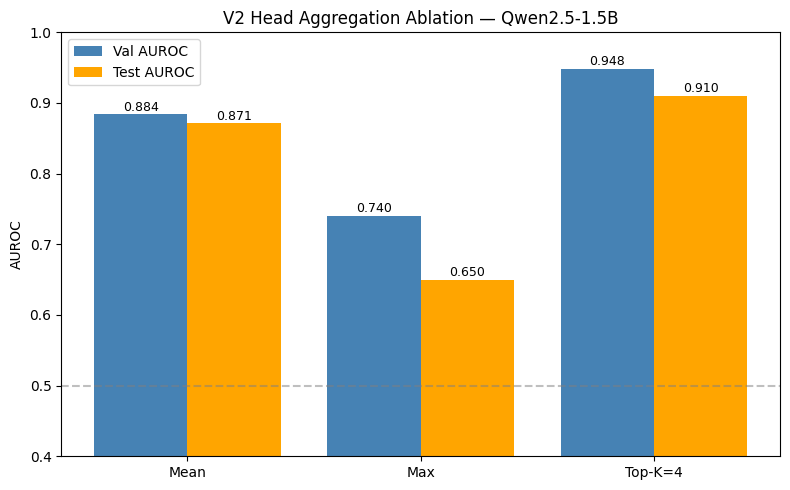

✅ V2 done! Plot saved!


In [ ]:
names = list(results_v2.keys())
val_scores  = [results_v2[n]["val_auroc"]  for n in names]
test_scores = [results_v2[n]["test_auroc"] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar(x - 0.2, val_scores,  0.4, label='Val AUROC',  color='steelblue')
bars2 = ax.bar(x + 0.2, test_scores, 0.4, label='Test AUROC', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('AUROC')
ax.set_title('V2 Head Aggregation Ablation — Qwen2.5-1.5B')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('v2_head_aggregation_qwen.png', dpi=150)
plt.show()
print("✅ V2 done! Plot saved!")

V3 Cross-Architecture — Qwen2.5-1.5B
Best Layer 15 LR          Val: 0.8841 | Test: 0.8713
All-Layer LR              Val: 0.8954 | Test: 0.8741
All-Layer MLP             Val: 0.9090 | Test: 0.9033


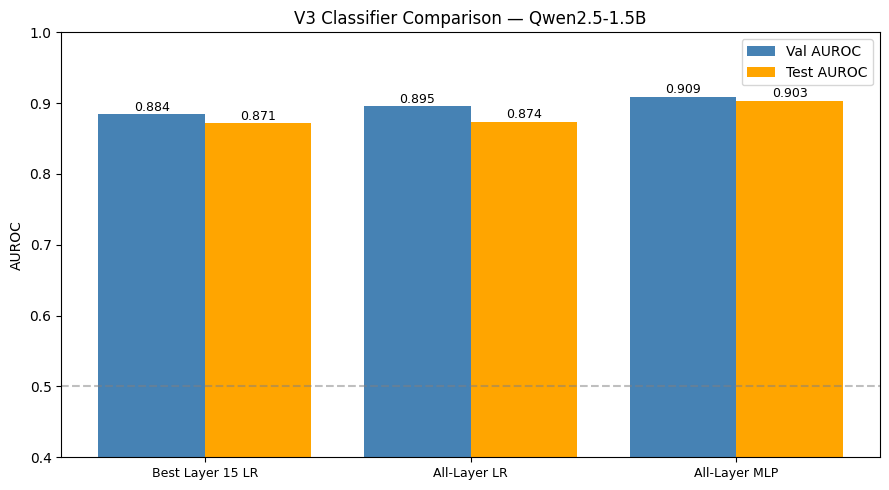

✅ V3 done!


In [ ]:
# V3 — Compare Best Layer vs All-Layer LR vs All-Layer MLP
from sklearn.neural_network import MLPClassifier

X_train_q, X_temp_q, y_train_q, y_temp_q = train_test_split(X_qwen, y, test_size=0.3, random_state=42, stratify=y)
X_val_q, X_test_q, y_val_q, y_test_q = train_test_split(X_temp_q, y_temp_q, test_size=0.5, random_state=42, stratify=y_temp_q)

best_layer = qwen_results['best_layer']

# 1. Best layer LR
clf_bl = LogisticRegression(max_iter=1000)
clf_bl.fit(X_train_q[:, best_layer].reshape(-1,1), y_train_q)
bl_val  = roc_auc_score(y_val_q,  clf_bl.predict_proba(X_val_q[:,  best_layer].reshape(-1,1))[:,1])
bl_test = roc_auc_score(y_test_q, clf_bl.predict_proba(X_test_q[:, best_layer].reshape(-1,1))[:,1])

# 2. All-layer LR
clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_q, y_train_q)
lr_val  = roc_auc_score(y_val_q,  clf_lr.predict_proba(X_val_q)[:,1])
lr_test = roc_auc_score(y_test_q, clf_lr.predict_proba(X_test_q)[:,1])

# 3. All-layer MLP
clf_mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
clf_mlp.fit(X_train_q, y_train_q)
mlp_val  = roc_auc_score(y_val_q,  clf_mlp.predict_proba(X_val_q)[:,1])
mlp_test = roc_auc_score(y_test_q, clf_mlp.predict_proba(X_test_q)[:,1])

results_v3 = {
    f"Best Layer {best_layer+1} LR": {"val": round(bl_val,4),  "test": round(bl_test,4)},
    "All-Layer LR":                  {"val": round(lr_val,4),  "test": round(lr_test,4)},
    "All-Layer MLP":                 {"val": round(mlp_val,4), "test": round(mlp_test,4)}
}

print("="*50)
print("V3 Cross-Architecture — Qwen2.5-1.5B")
print("="*50)
for name, r in results_v3.items():
    print(f"{name:25s} Val: {r['val']:.4f} | Test: {r['test']:.4f}")

# Plot
names = list(results_v3.keys())
val_s  = [results_v3[n]["val"]  for n in names]
test_s = [results_v3[n]["test"] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9,5))
bars1 = ax.bar(x - 0.2, val_s,  0.4, label='Val AUROC',  color='steelblue')
bars2 = ax.bar(x + 0.2, test_s, 0.4, label='Test AUROC', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('AUROC')
ax.set_title('V3 Classifier Comparison — Qwen2.5-1.5B')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('v3_cross_arch_qwen.png', dpi=150)
plt.show()
print("✅ V3 done!")

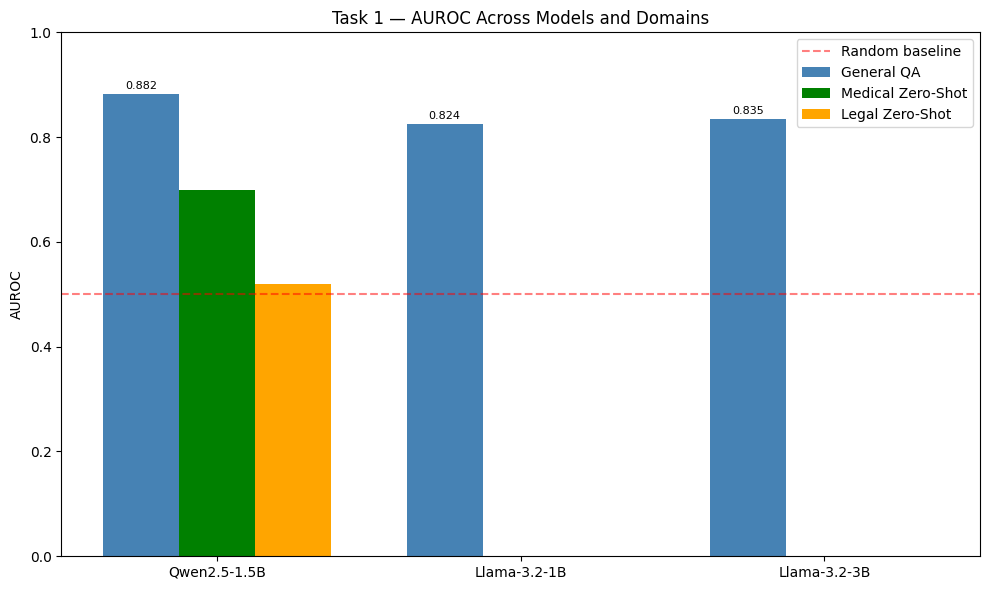

✅ Final plot saved!


In [ ]:
# Final summary plot
models = ['Qwen2.5-1.5B', 'Llama-3.2-1B', 'Llama-3.2-3B']
general_auroc  = [0.8819, 0.8243, 0.835]
medical_auroc  = [0.6993, None, None]
legal_auroc    = [0.52,   None, None]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x - width, general_auroc, width, label='General QA', color='steelblue')
bars2 = ax.bar(x,         [0.6993, 0, 0], width, label='Medical Zero-Shot', color='green')
bars3 = ax.bar(x + width, [0.52,   0, 0], width, label='Legal Zero-Shot',   color='orange')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel('AUROC')
ax.set_title('Task 1 — AUROC Across Models and Domains')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('final_auroc_comparison.png', dpi=150)
plt.show()
print("✅ Final plot saved!")

In [21]:
!pip install netcal -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.0/236.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 13.2 MB/s eta 0:00:00


In [24]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

False


AssertionError: Torch not compiled with CUDA enabled

In [22]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.model_selection import train_test_split
from netcal.metrics import ECE
import time, json, gc, os
import matplotlib.pyplot as plt
from huggingface_hub import login

login(token="YOUR_HF_TOKEN_HERE")

print("All imports done!")
print("GPU:", torch.cuda.get_device_name(0))

All imports done!


AssertionError: Torch not compiled with CUDA enabled

In [ ]:
gc.collect()
torch.cuda.empty_cache()

print("Loading Llama-3.2-1B...")
tokenizer_1b = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B-Instruct")
model_1b = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-1B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)
model_1b.eval()
print("Loaded! Layers:", model_1b.config.num_hidden_layers)

Loading Llama-3.2-1B...


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Loaded! Layers: 16


In [10]:
def extract_entropy(questions, answers, model, tokenizer, n_layers):
    features = []
    start = time.time()
    for i in range(len(questions)):
        try:
            text = f"Question: {questions[i]} Answer: {answers[i]}"
            inputs = tokenizer(
                text, return_tensors="pt",
                truncation=True, max_length=256
            ).to(model.device)

            with torch.no_grad():
                outputs = model(**inputs, output_attentions=True)

            layer_entropies = []
            for layer_attn in outputs.attentions:
                attn = layer_attn[0].float()
                valid = []
                for head in range(attn.shape[0]):
                    for token in range(attn.shape[1]):
                        row = attn[head, token, :]
                        if torch.isnan(row).any() or row.sum() < 1e-10:
                            continue
                        row = row / row.sum()
                        row = torch.clamp(row, min=1e-10)
                        valid.append(-torch.sum(row * torch.log(row)).item())
                layer_entropies.append(np.mean(valid) if valid else 0.0)
            features.append(layer_entropies)

        except Exception as e:
            print(f"Sample {i} failed: {e}")
            features.append([0.0] * n_layers)

        if (i+1) % 50 == 0:
            elapsed = time.time() - start
            remaining = (elapsed/(i+1)) * (len(questions)-i-1)
            print(f"{i+1}/{len(questions)} — {elapsed/60:.1f}min elapsed — {remaining/60:.1f}min left")

    print(f"Done in {(time.time()-start)/60:.1f} mins")
    return np.array(features)

print("✅ Ready!")

✅ Ready!


In [ ]:
print("Extracting Llama-1B entropy...")
X_1b = extract_entropy(sample_questions, sample_answers, model_1b, tokenizer_1b, model_1b.config.num_hidden_layers)
print("Shape:", X_1b.shape)
np.save(f"{SAVE_DIR}/X_1b.npy", X_1b)
np.save(f"{SAVE_DIR}/y.npy", y)
print("✅ Llama-1B saved!")

Extracting Llama-1B entropy...
50/500 — 3.2min elapsed — 28.4min left
100/500 — 6.6min elapsed — 26.5min left
150/500 — 9.9min elapsed — 23.2min left
200/500 — 13.2min elapsed — 19.8min left
250/500 — 16.3min elapsed — 16.3min left
300/500 — 19.4min elapsed — 12.9min left
350/500 — 22.9min elapsed — 9.8min left
400/500 — 26.0min elapsed — 6.5min left
450/500 — 29.0min elapsed — 3.2min left
500/500 — 31.9min elapsed — 0.0min left
Done in 31.9 mins
Shape: (500, 16)
✅ Llama-1B saved!


In [ ]:
print("Measuring Llama-1B latency...")
start = time.time()
for i in range(10):
    text = f"Question: {sample_questions[i]} Answer: {sample_answers[i]}"
    inputs = tokenizer_1b(text, return_tensors="pt", truncation=True, max_length=256).to(model_1b.device)
    with torch.no_grad():
        model_1b(**inputs, output_attentions=True)
latency_1b = (time.time() - start) / 10 * 1000
print(f"✅ Llama-1B latency: {latency_1b:.1f} ms/query")

del model_1b, tokenizer_1b
gc.collect()
torch.cuda.empty_cache()
print("Llama-1B cleared!")

Measuring Llama-1B latency...
✅ Llama-1B latency: 114.4 ms/query
Llama-1B cleared!


In [18]:
gc.collect()
torch.cuda.empty_cache()

print("Loading Llama-3.2-3B...")
tokenizer_3b = AutoTokenizer.from_pretrained(
    "meta-llama/Llama-3.2-3B-Instruct",
    force_download=True
)
model_3b = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-3B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
    force_download=True
)
model_3b.eval()
print("Loaded! Layers:", model_3b.config.num_hidden_layers)

NameError: name 'gc' is not defined

In [16]:
print("Loading Llama-3.2-3B...")
tokenizer_3b = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct")
model_3b = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-3B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)
model_3b.eval()
print("Loaded! Layers:", model_3b.config.num_hidden_layers)

Loading Llama-3.2-3B...


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

OSError: meta-llama/Llama-3.2-3B-Instruct does not appear to have files named ('model-00001-of-00002.safetensors', 'model-00002-of-00002.safetensors'). Checkout 'https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct/tree/main'for available files.

In [8]:
import os
import numpy as np
from datasets import load_dataset

SAVE_DIR = './DSA8_Task1_Final'
os.makedirs(SAVE_DIR, exist_ok=True)

dataset = load_dataset("pminervini/HaluEval", "qa")
data = dataset["data"]

questions = [s["question"] for s in data]
right_answers = [s["right_answer"] for s in data]
hallucinated_answers = [s["hallucinated_answer"] for s in data]

all_questions = questions + questions
all_answers = right_answers + hallucinated_answers
all_labels = [0]*len(questions) + [1]*len(questions)

np.random.seed(42)
indices = np.random.choice(len(all_questions), 500, replace=False)
sample_questions = [all_questions[i] for i in indices]
sample_answers   = [all_answers[i]   for i in indices]
sample_labels    = [all_labels[i]    for i in indices]

y = np.array(sample_labels)

# Save y
np.save(f"{SAVE_DIR}/y.npy", y)

print(f"Samples: {len(sample_questions)}")
print(f"y shape: {y.shape}")
print(f"Faithful: {sample_labels.count(0)}")
print(f"Hallucinated: {sample_labels.count(1)}")
print("✅ Ready!")

Samples: 500
y shape: (500,)
Faithful: 248
Hallucinated: 252
✅ Ready!


In [25]:
import os
files = os.listdir('.')
print(files)

['.config', 'DSA8_Task1_Final', 'sample_data']


In [26]:
import os
files = os.listdir('./DSA8_Task1_Final')
print(files)

['y.npy']


In [27]:
import os
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.npy') or file.endswith('.json'):
            print(os.path.join(root, file))

./.config/.last_update_check.json
./DSA8_Task1_Final/y.npy
./sample_data/anscombe.json
